In [57]:
#Dependencias que utiiza el archivo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [58]:
#lee el archivo excel y lo guarda en un dataframe
df=pd.read_excel("Short_Laprida_Sian_TPINTEGRADOR.xlsx",sheet_name="Hoja1",header=1)

# Limpieza de dataframe

In [59]:
#Eliminacion de columnas que se generaron erroneamente al leer el archivo excel
df=df.drop(columns={"Unnamed: 0","Unnamed: 1"})

In [62]:
#Normalizando la columna "Promedio diario de desbloqueo de pantalla" a tipo numerico para asi reemplazar los valores que no son numericos por Nan
df["Promedio diario de desbloqueo de pantalla"]=pd.to_numeric( df["Promedio diario de desbloqueo de pantalla"],errors="coerce")

In [63]:
#Reemplazando los valores Nan por el promedio de la columna
df["Promedio diario de desbloqueo de pantalla"]=df["Promedio diario de desbloqueo de pantalla"].fillna(df["Promedio diario de desbloqueo de pantalla"].mean())

# Definicion de las variables necesarias para la regresion linea

In [64]:
#Definiendo la variable independiente y dependiente
horas_promedio_redes=df["Horas promedio en redes sociales"]
print("Variable independiente:",horas_promedio_redes)
rendimiento_academico=df["Rendimiento academico"]
print("Variable dependiente:",rendimiento_academico)

Variable independiente: 0      4.0
1      6.0
2      2.0
3      3.0
4      1.0
      ... 
206    4.1
207    2.5
208    6.3
209    1.5
210    5.3
Name: Horas promedio en redes sociales, Length: 211, dtype: float64
Variable dependiente: 0      7
1      6
2      8
3      5
4      9
      ..
206    8
207    8
208    6
209    8
210    7
Name: Rendimiento academico, Length: 211, dtype: int64


In [65]:
#Creando un nuevo dataframe para almacenar las variables que necesita la regresion lineal
df_2=pd.DataFrame({"X":horas_promedio_redes,"y":rendimiento_academico})

In [66]:
#definiendo y añadiendo nuevas columnas 
df_2["x*y"]=df_2["X"]*df_2["y"]
df_2["x^2"]=df_2["X"]**2
df_2["y^2"]=df_2["y"]**2

In [67]:
# Calculando las sumatorias
print("\n Sumatoria")

xSum =df_2["X"].sum()
print("Suma X:", xSum)
ySum =df_2["y"].sum()
print("Suma Y:", ySum)
xySum=df_2["x*y"].sum()
print("Suma XY:", xySum)
x2Sum=df_2["x^2"].sum()
print("Suma X^2:", x2Sum)
y2Sum=df_2["y^2"].sum()
print("Suma Y^2:", y2Sum)
n=len(df_2)


 Sumatoria
Suma X: 755.0
Suma Y: 1488
Suma XY: 5097.0
Suma X^2: 3354.84
Suma Y^2: 10884


# Recta de regresion

In [68]:
# Calculo de coeficientes de regresion lineal
b=((n * xySum) - (xSum * ySum)) / ((n * x2Sum) - (xSum ** 2))

a = ((ySum * x2Sum) - (xySum * xSum)) / ((n * x2Sum) - (xSum ** 2))
print("\nRecta de regresion")
print(f" y= {a:.2f} + {b:.2f}x")


Recta de regresion
 y= 8.30 + -0.35x


In [69]:
#Calculo de correlacion
r = ((n * xySum) - (xSum * ySum)) / np.sqrt(((n * x2Sum) - (xSum ** 2)) * ((n * y2Sum) - (ySum ** 2)))
print("\n Correlacion")
print(f"r ={r:.4f}")
r2=r**2
print(f"r^2= {r2:.4f}")



 Correlacion
r =-0.4502
r^2= 0.2027


In [70]:
# Interpretacion de la correlacion
if r>0:
    print("\n La correlacion es positiva")
elif r<0:
    print("\n La correlacion es negativa")
else:
    print("\n No existe una correlacion")

print(f"El modelo explica aproximadamente el {r2*100:.2f}% de la variabilidad.")


 La correlacion es negativa
El modelo explica aproximadamente el 20.27% de la variabilidad.


In [71]:
# Interpretacion de la fuerza de la correlacion
if abs(r) >= 0.8:
    fuerza = "muy fuerte"
elif abs(r) >= 0.5:
    fuerza = "moderada"
elif abs(r) >= 0.3:
    fuerza = "débil"
else:
    fuerza = "muy débil o nula"
print(f"La fuerza de la correlación es {fuerza}.")

La fuerza de la correlación es débil.


# Diagrama de dispercion con recta de regresion

In [72]:
#Se variable para la recta de regresion lineal
x_line=np.linspace(horas_promedio_redes.min(),horas_promedio_redes.max(),100)
y_line=a+b*x_line

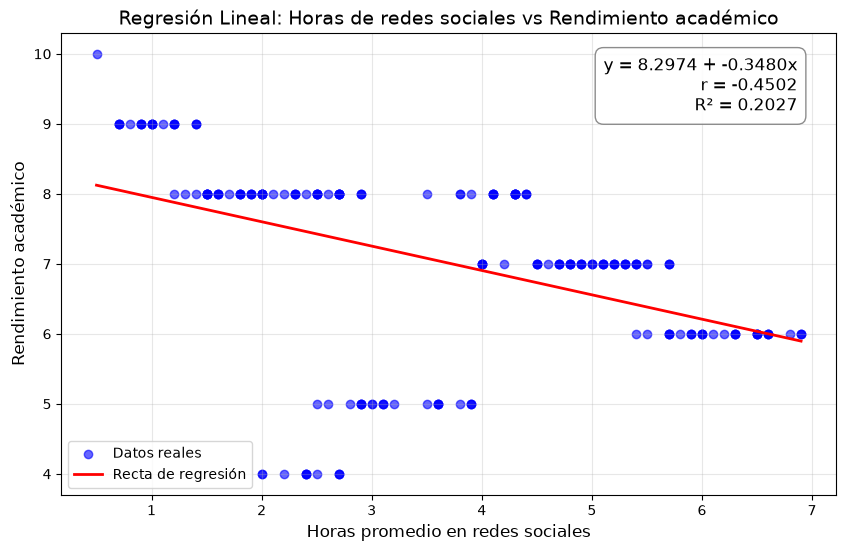

In [73]:
#Creacion del grafico de dispersion
plt.figure(figsize=(10, 6))
plt.scatter(horas_promedio_redes,rendimiento_academico,alpha=0.6,color="blue",label="Datos reales")
plt.plot(x_line, y_line, color='red', linewidth=2, label='Recta de regresión')

# Título y etiquetas
plt.title("Regresión Lineal: Horas de redes sociales vs Rendimiento académico", fontsize=14)
plt.xlabel("Horas promedio en redes sociales", fontsize=12)
plt.ylabel("Rendimiento académico", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.text(0.95, 0.95, 
        f'y = {a:.4f} + {b:.4f}x\nr = {r:.4f}\nR² = {r2:.4f}', 
        transform=plt.gca().transAxes, 
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9))
plt.show()